/tmp/ipykernel_3726434/4149415771.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["origin"] = name


Pearson Correlation with 'delta_total':
Y                         1.000000
delta_total_accepted      1.000000
dG_binding_IE_accepted    0.361214
dG_binding_IE             0.361214
Average_dG                0.306978
                            ...   
Target_rejected                NaN
proteina_rejected              NaN
Target_length                  NaN
proteina_length                NaN
dG_binding_IE_err              NaN
Name: delta_total, Length: 238, dtype: float64


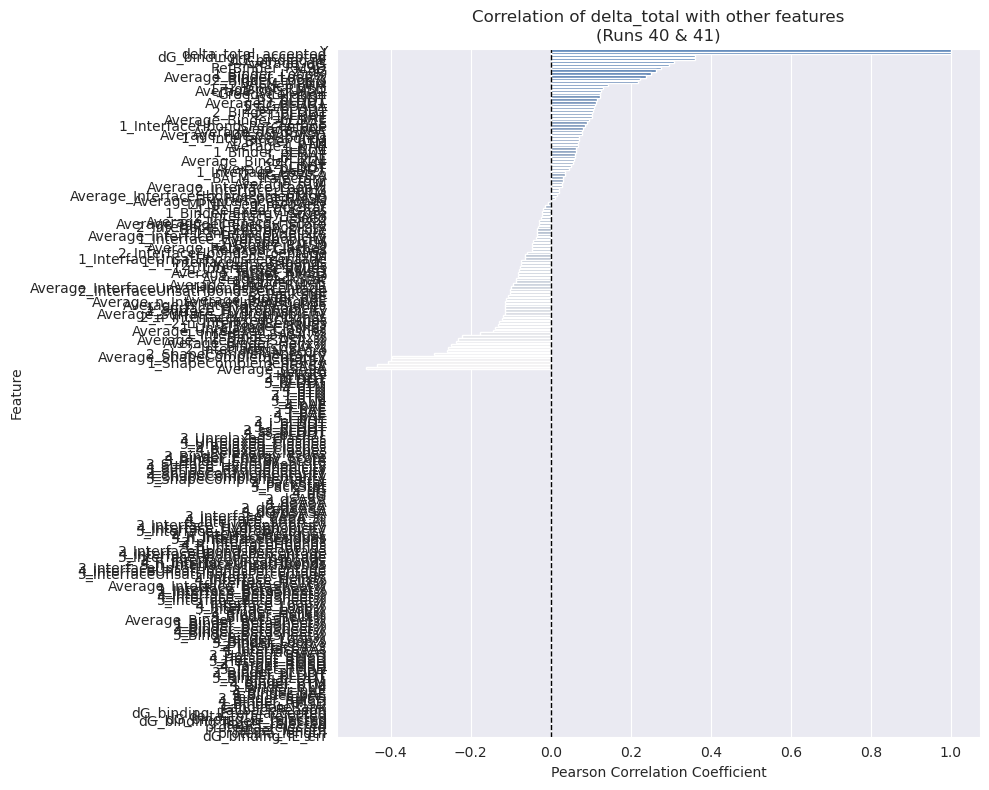

In [35]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

base = Path("/FastHome/gyula/designs/place_holder/DATA")

# Target only the two specified runs
names = [
    "gy_2nd_iter_try_40_fixed_new_filters",
    "gy_2nd_iter_try_41_more_iter"
]

frames = []
for name in names:
    csv_path = base / name / "mpnn_design_stats_augmented_with_ntoc.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df["origin"] = name
        frames.append(df)
    else:
        print(f"Warning: {csv_path} not found.")

if frames:
    all_df = pd.concat(frames, ignore_index=True)

    # Optional: uncomment if you still want to filter by Length
    # all_df = all_df.loc[all_df.Length == 15]

    # Select only numeric columns to calculate correlations
    numeric_df = all_df.select_dtypes(include=['number'])

    # Calculate Pearson correlation matrix
    corr_matrix = numeric_df.corr()

    # Extract 'delta_total' correlations, exclude itself, and sort
    if 'delta_total' in corr_matrix.columns:
        delta_corr = corr_matrix['delta_total'].drop('delta_total').sort_values(ascending=False)

        print("Pearson Correlation with 'delta_total':")
        print(delta_corr)

        # Plotting the correlations
        plt.figure(figsize=(10, 8))
        # Using a diverging palette to clearly show positive vs negative correlations
        sns.barplot(x=delta_corr.values, y=delta_corr.index, hue=delta_corr.index, palette="vlag", legend=False)

        # Add a vertical line at 0 for visual reference
        plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

        plt.title("Correlation of delta_total with other features\n(Runs 40 & 41)")
        plt.xlabel("Pearson Correlation Coefficient")
        plt.ylabel("Feature")
        plt.tight_layout()

        # Save to the all_runs directory
        outdir = base / "all_runs"
        outdir.mkdir(exist_ok=True)
        plt.savefig(outdir / "delta_total_correlations.png", dpi=300)

        plt.show()
        plt.close()
    else:
        print("'delta_total' not found in numeric columns.")
else:
    print("No valid CSV files were loaded.")

In [36]:
delta_corr.n_to_c


np.float64(0.031092881060390636)

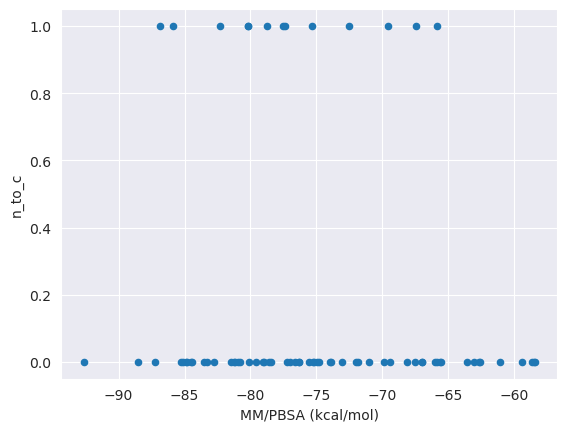

In [37]:
df.plot.scatter(x='delta_total', y='n_to_c')
plt.xlabel("MM/PBSA (kcal/mol)")
plt.show()